In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('wine_data.csv', header = None, usecols=[0,1,2])
df.columns = ['Class label', 'Alcohol', 'Malic Acid']

print(df.shape)
print(df.head)
print("\n Class distribution :")
print(df['Class label'].value_counts())
print("\n Basic statiastics : ")
print(df.describe().round(2))

(178, 3)
<bound method NDFrame.head of      Class label  Alcohol  Malic Acid
0              1    14.23        1.71
1              1    13.20        1.78
2              1    13.16        2.36
3              1    14.37        1.95
4              1    13.24        2.59
..           ...      ...         ...
173            3    13.71        5.65
174            3    13.40        3.91
175            3    13.27        4.28
176            3    13.17        2.59
177            3    14.13        4.10

[178 rows x 3 columns]>

 Class distribution :
Class label
2    71
1    59
3    48
Name: count, dtype: int64

 Basic statiastics : 
       Class label  Alcohol  Malic Acid
count       178.00   178.00      178.00
mean          1.94    13.00        2.34
std           0.78     0.81        1.12
min           1.00    11.03        0.74
25%           1.00    12.36        1.60
50%           2.00    13.05        1.87
75%           3.00    13.68        3.08
max           3.00    14.83        5.80


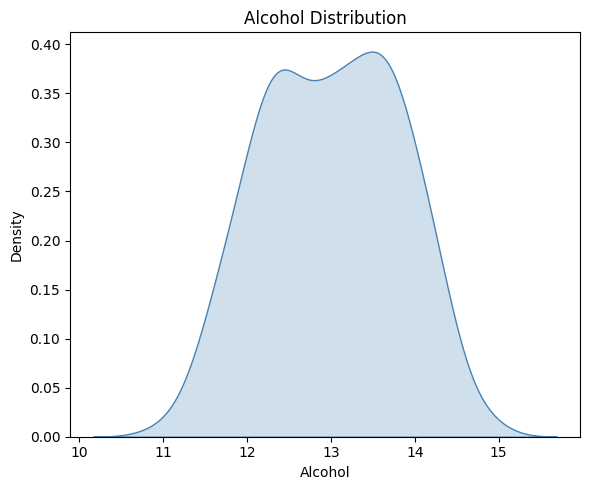

In [2]:
# KDE : Alchohol Distribution
fig, ax = plt.subplots(figsize=(6, 5))
sns.kdeplot(df['Alcohol'], ax=ax, fill=True, color='steelblue')
ax.set_title("Alcohol Distribution")
ax.set_xlabel("Alcohol")
plt.tight_layout()
plt.show()

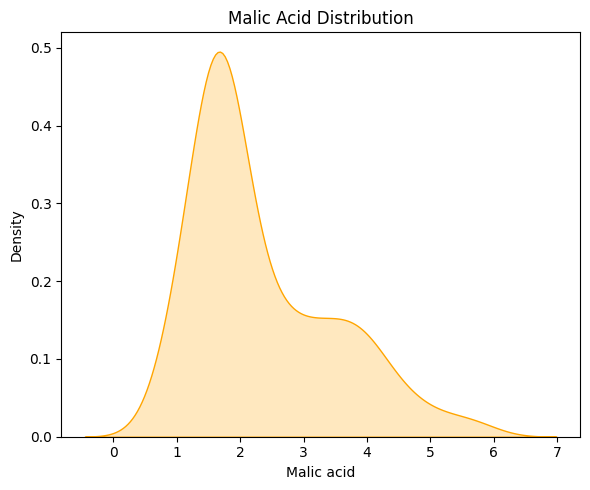

In [4]:
# KDE : Malic Acid distribution
fig, ax = plt.subplots(figsize=(6, 5))
sns.kdeplot(df['Malic Acid'], ax=ax, fill=True, color='orange')
ax.set_title("Malic Acid Distribution")
ax.set_xlabel("Malic acid")
plt.tight_layout()
plt.show()

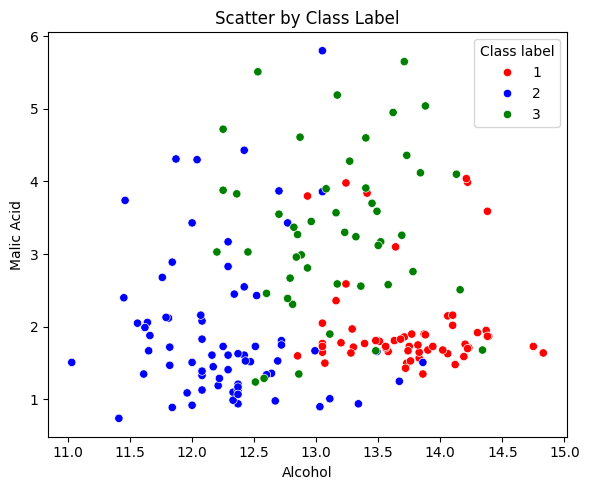

In [6]:
# Scatter plot by class label
color_dict = {1: 'red', 2: 'blue', 3: 'green'}

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(
    x=df['Alcohol'],
    y=df['Malic Acid'],
    hue=df['Class label'],
    palette=color_dict,
    ax=ax
)
ax.set_title("Scatter by Class Label")
plt.tight_layout()
plt.show()

In [7]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Class label', axis=1),
    df['Class label'],
    test_size=0.3,
    random_state=0
)

print("Train shape:", X_train.shape)   # (124, 2)
print("Test shape :", X_test.shape)    # (54,  2)
print("\nBefore scaling stats:")
print(np.round(X_train.describe(), 2))

Train shape: (124, 2)
Test shape : (54, 2)

Before scaling stats:
       Alcohol  Malic Acid
count   124.00      124.00
mean     12.98        2.38
std       0.80        1.14
min      11.03        0.89
25%      12.36        1.61
50%      13.04        1.88
75%      13.64        3.25
max      14.75        5.65


In [8]:
# Apply MinMxScaler
scaler = MinMaxScaler()

# STEP 1 : Fit only on training data --> it learns min and max
scaler.fit(X_train)

# See what it has learnt
print("Min learned from train:")
print(f"  Alcohol min    : {scaler.data_min_[0]:.2f}")
print(f"  Malic acid min : {scaler.data_min_[1]:.2f}")
print("\nMax learned from train:")
print(f"  Alcohol max    : {scaler.data_max_[0]:.2f}")
print(f"  Malic acid max : {scaler.data_max_[1]:.2f}")

# STEP 2 : Tranform both train and test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 3 : convert back to dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

# Compare before and after
print("\nBEFORE normalization:")
print(np.round(X_train.describe(), 2))

print("\nAFTER normalization:")
print(np.round(X_train_scaled.describe(), 2))

Min learned from train:
  Alcohol min    : 11.03
  Malic acid min : 0.89

Max learned from train:
  Alcohol max    : 14.75
  Malic acid max : 5.65

BEFORE normalization:
       Alcohol  Malic Acid
count   124.00      124.00
mean     12.98        2.38
std       0.80        1.14
min      11.03        0.89
25%      12.36        1.61
50%      13.04        1.88
75%      13.64        3.25
max      14.75        5.65

AFTER normalization:
       Alcohol  Malic Acid
count   124.00      124.00
mean      0.53        0.31
std       0.22        0.24
min       0.00        0.00
25%       0.36        0.15
50%       0.54        0.21
75%       0.70        0.50
max       1.00        1.00


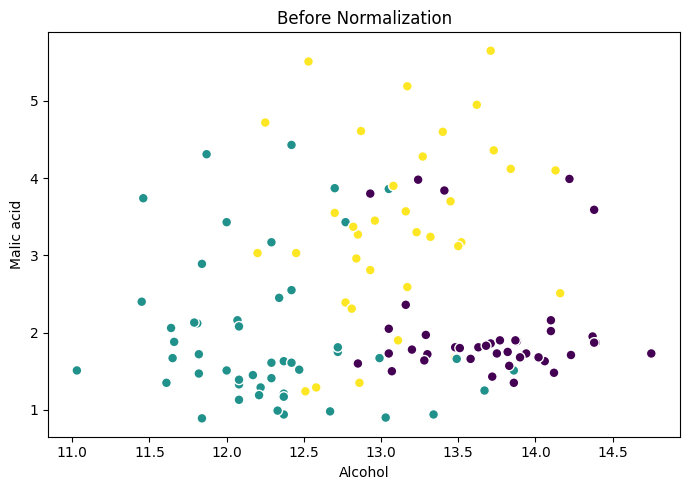

In [15]:
# Scatter before Normalization
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train['Alcohol'], X_train['Malic Acid'],
           c=y_train, edgecolors='white', s=50)
ax.set_title("Before Normalization")
ax.set_xlabel("Alcohol")
ax.set_ylabel("Malic acid")
plt.tight_layout()
plt.show()

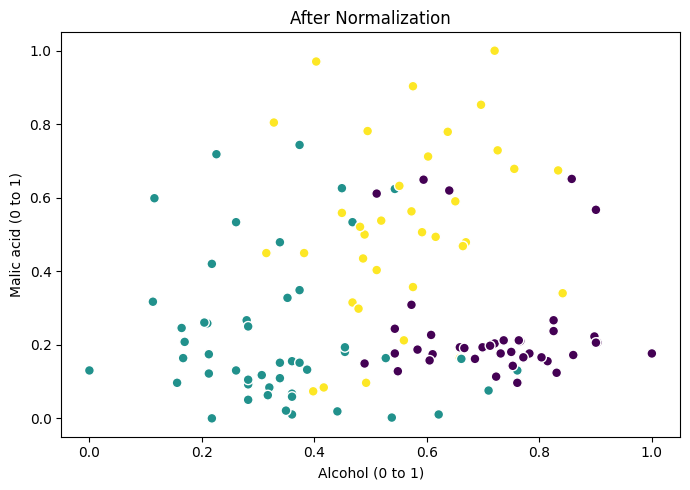

In [17]:
# Scatter After normalization
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic Acid'],
           c=y_train, edgecolors='white', s=50)
ax.set_title("After Normalization")
ax.set_xlabel("Alcohol (0 to 1)")
ax.set_ylabel("Malic acid (0 to 1)")
plt.tight_layout()
plt.show()

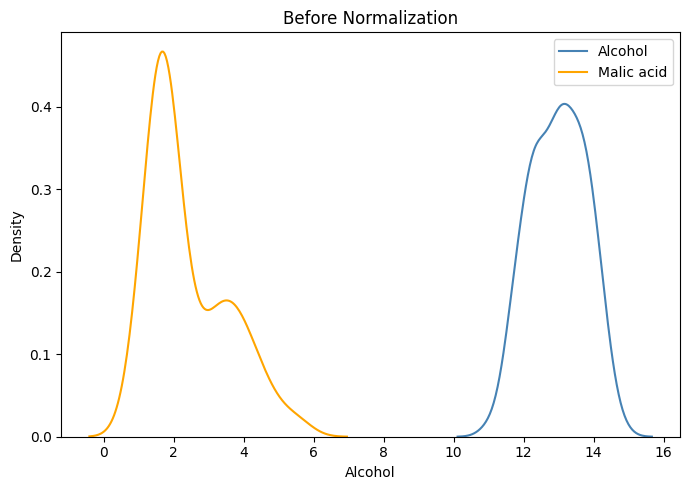

In [19]:
# KDE Before normalization
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Before Normalization')
sns.kdeplot(X_train['Alcohol'],    ax=ax, label='Alcohol',    color='steelblue')
sns.kdeplot(X_train['Malic Acid'], ax=ax, label='Malic acid', color='orange')
ax.legend()
plt.tight_layout()
plt.show()

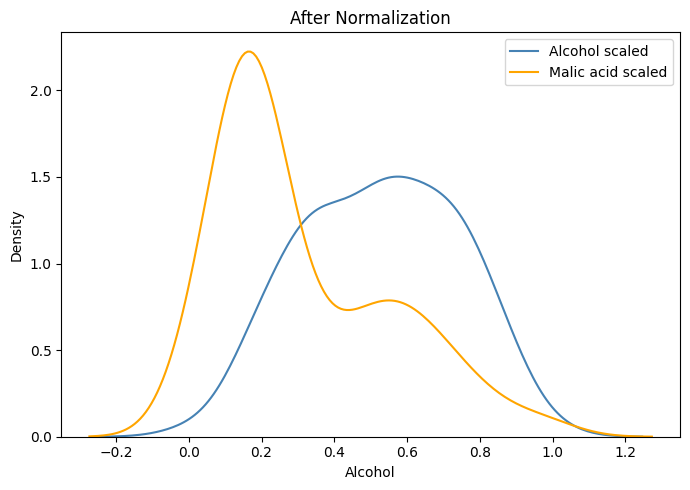

In [20]:
# KDE After normalization
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('After Normalization')
sns.kdeplot(X_train_scaled['Alcohol'],    ax=ax, label='Alcohol scaled',    color='steelblue')
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax, label='Malic acid scaled', color='orange')
ax.legend()
plt.tight_layout()
plt.show()

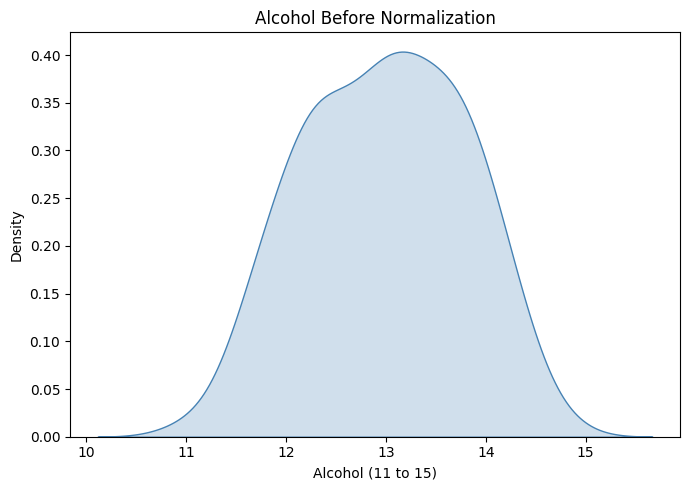

In [22]:
# KDE : Alocohol before Normalization
fig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(X_train['Alcohol'], ax=ax, fill=True, color='steelblue')
ax.set_title('Alcohol Before Normalization')
ax.set_xlabel('Alcohol (11 to 15)')
plt.tight_layout()
plt.show()

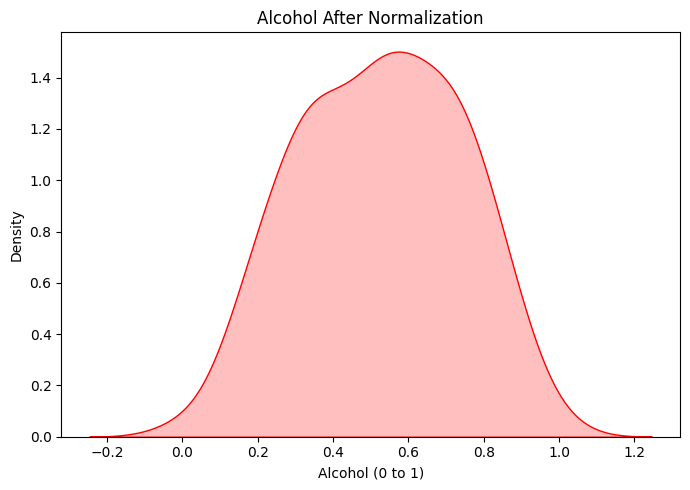

In [23]:
# KDE: Alcohol After Normalization
pythonfig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax, fill=True, color='red')
ax.set_title('Alcohol After Normalization')
ax.set_xlabel('Alcohol (0 to 1)')
plt.tight_layout()
plt.show()

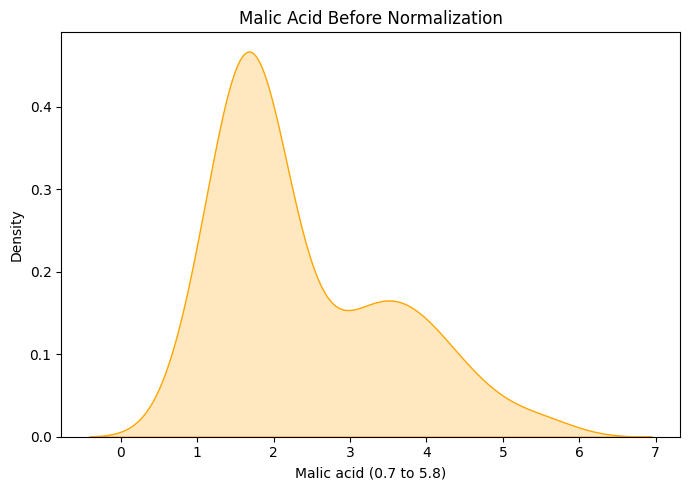

In [25]:
# KDE: Malic Acid Before Normalization
pythonfig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(X_train['Malic Acid'], ax=ax, fill=True, color='orange')
ax.set_title('Malic Acid Before Normalization')
ax.set_xlabel('Malic acid (0.7 to 5.8)')
plt.tight_layout()
plt.show()

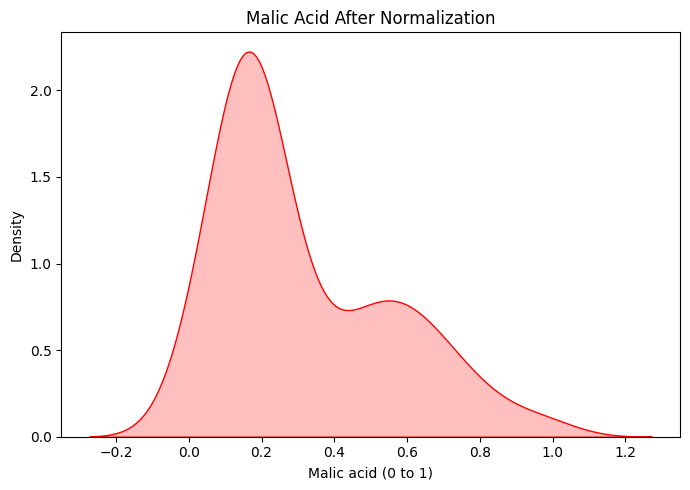

In [27]:
# KDE: Malic Acid After Normalization
pythonfig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax, fill=True, color='red')
ax.set_title('Malic Acid After Normalization')
ax.set_xlabel('Malic acid (0 to 1)')
plt.tight_layout()
plt.show()

In [28]:
# ── KNN is heavily affected by scaling ────────────────────
# KNN uses distance between points
# unscaled → Malic acid distances dominate
# scaled   → both features contribute equally

print("KNN — Effect of Normalization")

for k in [3, 5, 7, 9]:
    knn        = KNeighborsClassifier(n_neighbors=k)
    knn_scaled = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)
    knn_scaled.fit(X_train_scaled, y_train)

    acc        = accuracy_score(y_test, knn.predict(X_test))
    acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

    print(f"K={k} | Unscaled: {acc:.4f} | Scaled: {acc_scaled:.4f} | Diff: {(acc_scaled-acc)*100:+.1f}%")

print()

#  Logistic Regression 
print("LOGISTIC REGRESSION — Effect of Normalization")

lr        = LogisticRegression(max_iter=1000)
lr_scaled = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

acc        = accuracy_score(y_test, lr.predict(X_test))
acc_scaled = accuracy_score(y_test, lr_scaled.predict(X_test_scaled))

print(f"Unscaled : {acc:.4f}")
print(f"Scaled   : {acc_scaled:.4f}")
print(f"Diff     : {(acc_scaled-acc)*100:+.1f}%")

KNN — Effect of Normalization
K=3 | Unscaled: 0.7963 | Scaled: 0.7778 | Diff: -1.9%
K=5 | Unscaled: 0.8148 | Scaled: 0.8148 | Diff: +0.0%
K=7 | Unscaled: 0.8704 | Scaled: 0.8148 | Diff: -5.6%
K=9 | Unscaled: 0.8333 | Scaled: 0.8333 | Diff: +0.0%

LOGISTIC REGRESSION — Effect of Normalization
Unscaled : 0.7593
Scaled   : 0.7963
Diff     : +3.7%


## Normalization (MinMax)

| | Use Case |
|---|---|
| ✅ | When you need values between 0 and 1 |
| ✅ | Neural Networks (inputs should be 0-1) |
| ✅ | Image processing (pixel values 0-255 → 0-1) |
| ✅ | When distribution is NOT normal |
| ❌ | Sensitive to outliers (one outlier shifts everything) |

## Standardization (Standard)

| | Use Case |
|---|---|
| ✅ | General purpose — works most of the time |
| ✅ | When outliers exist |
| ✅ | Linear/Logistic Regression, SVM |
| ✅ | When distribution is roughly normal |
| ✅ | No fixed range needed |